In [2]:
# Import
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display, HTML

def show_map(m):
    """Reliably display a geemap Map in Codespaces."""
    try:
        display(m)
    except Exception:
        display(HTML(m.to_html()))

print("✅ All imports successful!")

✅ All imports successful!


In [3]:
# Authenticate
ee.Authenticate()

True

In [4]:
# Initialize
PROJECT_ID = 'ee-xinranzhou2059'   # ⚠️ replace this

ee.Initialize(project=PROJECT_ID)
print(f"✅ Earth Engine initialized — project: {PROJECT_ID}")

✅ Earth Engine initialized — project: ee-xinranzhou2059


In [5]:
lat_north = 40.7666667
lat_south = 39.4833333
lon_west = -105.4666667
lon_east = -105.05



study_area = ee.Geometry.Rectangle([
[lon_west, lat_south], # SW
[lon_east, lat_north] # NE
])



Map = geemap.Map(center=[(lat_north+lat_south)/2, (lon_west+lon_east)/2], zoom=9)
Map.addLayer(study_area, {'color': 'red'}, 'Study Area Rectangle')
Map

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [6]:
nlcd_2001 = (ee.ImageCollection('USGS/NLCD_RELEASES/2019_REL/NLCD')
             .filter(ee.Filter.eq('system:index', '2001'))
             .first().select('landcover').clip(study_area))

nlcd_2021 = (ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD')
             .filter(ee.Filter.eq('system:index', '2021'))
             .first().select('landcover').clip(study_area))

# GEE knows NLCD's color palette — no vis_params needed
Map5 = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=14)
Map5.split_map(
    left_layer=geemap.ee_tile_layer(nlcd_2001, {}, 'NLCD 2001'),
    right_layer=geemap.ee_tile_layer(nlcd_2021, {}, 'NLCD 2021')
)
Map5.add_legend(title='NLCD Land Cover', builtin_legend='NLCD')
show_map(Map5)

Map(center=[40.125, -105.25833335], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

In [7]:
def apply_scale_factors(image):
    """Convert raw Landsat C2 L2 integers to surface reflectance (0–1)."""
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    return image.addBands(optical, overwrite=True) \
                .addBands(thermal, overwrite=True)

landsat_2024 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2'))
    .filterBounds(study_area)
    .filterDate('2024-06-01', '2024-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(apply_scale_factors)
    .median()
    .clip(study_area)
)

# Define visualization parameters for the blended RGB uint8 images
uint8_rgb_vis = {'bands': ['red', 'green', 'blue'], 'min': 0, 'max': 255}

# Prepare Landsat 2024 true color image with 'red', 'green', 'blue' bands.
# This ensures consistency for blending and final display.
landsat_2024_rgb = landsat_2024.select(

    ['SR_B4', 'SR_B3', 'SR_B2'],  # Original Landsat 8/9 bands for True Color
    ['red', 'green', 'blue']      # Renamed bands for consistent visualization
)

In [8]:
nlcd_change = nlcd_2001.select('landcover').neq(nlcd_2021.select('landcover'))
nlcd_change_reclassified = nlcd_change.remap([0, 1], [0, 1])

# Black for unchanged, red for changed
change_vis_combined = {'min': 0, 'max': 1, 'palette': ['000000', 'FF0000']}

Map_nlcd_change = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=9)

Map_nlcd_change.addLayer(landsat_2024_rgb, uint8_rgb_vis, 'Landsat 2024 True Color')
Map_nlcd_change.addLayer(nlcd_change_reclassified, change_vis_combined, 'NLCD Land Cover Change (2001-2021)')

# Legend
legend_dict = {
    'Unchanged': '#000000',
    'Changed': '#FF0000',
}

Map_nlcd_change.add_legend(legend_dict=legend_dict, title='Land Cover Status')

show_map(Map_nlcd_change)
Map_nlcd_change.to_html('nlcd_map_change.html')

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [9]:
import os

# Load MODIS burned area data for the entire period 2001-2021
burned_area_2001_2021 = (ee.ImageCollection('MODIS/061/MCD64A1')
                            .filterDate('2001-01-01', '2021-12-31')
                            .select('BurnDate')
                            .max()
                            .gt(0)
                            .selfMask()
                            .clip(study_area))

# Calculate and print the total number of burned pixels for the period
pixel_count_2001_2021 = burned_area_2001_2021.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=study_area,
    scale=500,
    maxPixels=1e9
).get('BurnDate').getInfo()

print(f"Burned pixels from 2001-2021 (MODIS): {pixel_count_2001_2021 if pixel_count_2001_2021 else 0}")

# Define visualization parameters for burned areas - ORANGE
fire_vis = {'palette': ['FFA500'], 'opacity': 0.7}

# Define border style for study area
border_vis = {
    'color': '000000',
    'width': 2,
    'fillColor': '00000000'
}

# Create map
Map_fire_aggregated = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=9)
Map_fire_aggregated.add_basemap('OpenStreetMap.Mapnik')

# Add study area border
Map_fire_aggregated.addLayer(study_area, border_vis, 'Study Area Boundary')

# Add burned areas overlay
Map_fire_aggregated.addLayer(burned_area_2001_2021, fire_vis, 'Burned Area 2001-2021')

# Legend
legend_dict = {'Burned Area': '#FFA500', 'Study Area Boundary': '#000000'}
Map_fire_aggregated.add_legend(legend_dict=legend_dict, title='Burned Area 2001-2021')

# Display ONLY the interactive map
Map_fire_aggregated.to_html('nlcd_map_change.html')
display(Map_fire_aggregated)

Burned pixels from 2001-2021 (MODIS): 3072.996078431373


Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

Burned pixels from 2001-2021 (MODIS): 3072.996078431373


Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

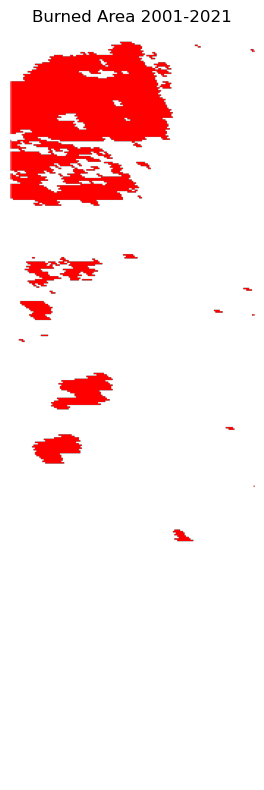

✅ Saved → figures/burned_area_2001_2021.png


In [10]:
import os

def get_ee_thumbnail(image, vis_params, region, size=512):
    """Fetch a GEE image as a PIL Image for matplotlib/savefig."""
    params = {**vis_params, 'region': region.getInfo(),
              'dimensions': size, 'format': 'png'}
    url = image.getThumbURL(params)
    return Image.open(BytesIO(requests.get(url).content))

# Load MODIS burned area data for the entire period 2001-2021
burned_area_2001_2021 = (ee.ImageCollection('MODIS/061/MCD64A1')
                            .filterDate('2001-01-01', '2021-12-31')
                            .select('BurnDate')
                            .max() # Use max to get any burn within the period
                            .gt(0)
                            .selfMask()
                            .clip(study_area))

# Calculate and print the total number of burned pixels for the period
pixel_count_2001_2021 = burned_area_2001_2021.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=study_area,
    scale=500, # MODIS resolution is 500m
    maxPixels=1e9
).get('BurnDate').getInfo()

print(f"Burned pixels from 2001-2021 (MODIS): {pixel_count_2001_2021 if pixel_count_2001_2021 else 0}")

# Define visualization parameters for burned areas (red)
fire_vis = {'palette': ['ff0000']}

# Create a map to display aggregated burned areas
Map_fire_aggregated = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=9)
Map_fire_aggregated.addLayer(burned_area_2001_2021, fire_vis, 'Burned Area 2001-2021')

# Add a legend for the fire data
Map_fire_aggregated.add_legend(title='Burned Area', legend_keys=['Burned'], legend_colors=['#ff0000'])

show_map(Map_fire_aggregated)

# Save the map as a static image
fire_thumb_aggregated = get_ee_thumbnail(burned_area_2001_2021, fire_vis, study_area)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(fire_thumb_aggregated)
ax.set_title('Burned Area 2001-2021')
ax.axis('off')
plt.tight_layout()

output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'burned_area_2001_2021.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved → figures/burned_area_2001_2021.png')

In [11]:
def count_classes(nlcd_image, year):
    """Return a dict of {class_code: pixel_count} for an NLCD image."""
    result = nlcd_image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=study_area, scale=30, maxPixels=1e9
    ).getInfo()
    counts = result['landcover']
    print(f"\n--- NLCD {year} (top classes) ---")
    for code, n in sorted(counts.items(), key=lambda x: -x[1])[:8]:
        print(f"  Class {code}: {n:,} pixels")
    return counts

counts_2001 = count_classes(nlcd_2001, 2001)
counts_2021 = count_classes(nlcd_2021, 2021)


--- NLCD 2001 (top classes) ---
  Class 42: 2,167,103.156862742 pixels
  Class 52: 1,012,100.7294117645 pixels
  Class 71: 851,773.6039215686 pixels
  Class 22: 364,883.60392156855 pixels
  Class 21: 278,222.6549019608 pixels
  Class 82: 221,813.87058823527 pixels
  Class 23: 212,638.86274509807 pixels
  Class 11: 104,948.72156862744 pixels

--- NLCD 2021 (top classes) ---
  Class 42: 1,744,347.5215686248 pixels
  Class 52: 1,135,103.454901961 pixels
  Class 71: 1,041,375.8549019608 pixels
  Class 22: 391,609.84705882345 pixels
  Class 21: 327,438.79215686274 pixels
  Class 23: 272,557.1725490197 pixels
  Class 82: 192,132.79215686268 pixels
  Class 11: 111,299.70588235295 pixels


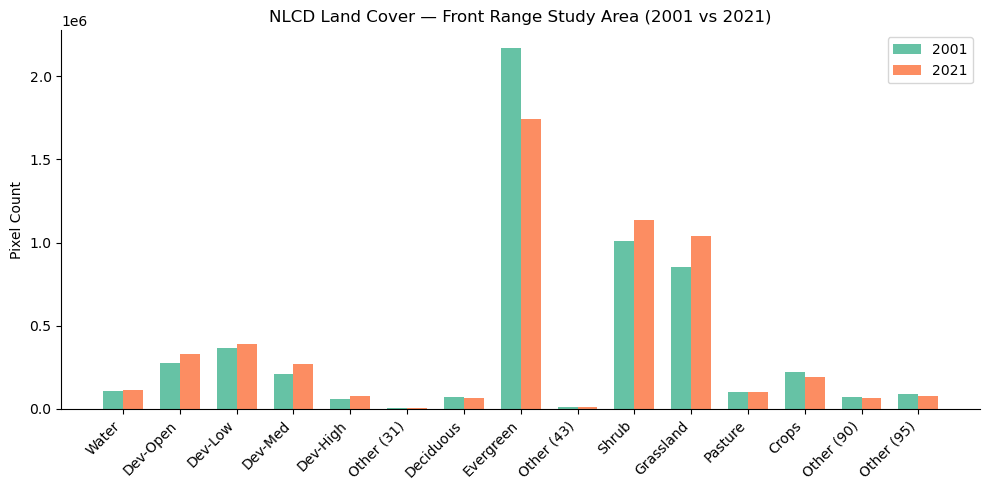

✅ Saved → figures/csu_nlcd_comparison.png


In [12]:
import pandas as pd

# Bar chart: 2001 vs 2021 side by side
nlcd_names = {
    '11':'Water','21':'Dev-Open','22':'Dev-Low','23':'Dev-Med','24':'Dev-High',
    '41':'Deciduous','42':'Evergreen','52':'Shrub','71':'Grassland',
    '81':'Pasture','82':'Crops'
}
all_classes = sorted(set(counts_2001) | set(counts_2021))
df = pd.DataFrame({
    'Class': [nlcd_names.get(c, f'Other ({c})') for c in all_classes],
    '2001':  [counts_2001.get(c, 0) for c in all_classes],
    '2021':  [counts_2021.get(c, 0) for c in all_classes],
})

fig, ax = plt.subplots(figsize=(10, 5))
x, w = range(len(df)), 0.35
ax.bar([i - w/2 for i in x], df['2001'], w, label='2001', color='#66c2a5')
ax.bar([i + w/2 for i in x], df['2021'], w, label='2021', color='#fc8d62')
ax.set_xticks(x); ax.set_xticklabels(df['Class'], rotation=45, ha='right')
ax.set_ylabel('Pixel Count')
ax.set_title('NLCD Land Cover — Front Range Study Area (2001 vs 2021)')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/csu_nlcd_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_nlcd_comparison.png")

In [13]:
# ✏️ largest increase and decrease
delta_counts = {cls: counts_2021.get(cls, 0) - counts_2001.get(cls, 0)
                for cls in set(counts_2001) | set(counts_2021)}

largest_gain = max(delta_counts.items(), key=lambda item: item[1])
largest_loss = min(delta_counts.items(), key=lambda item: item[1])

nlcd_names = {
    '11':'Water','12':'Perennial Ice/Snow','21':'Dev-Open','22':'Dev-Low','23':'Dev-Med','24':'Dev-High',
    '31':'Barren Land','41':'Deciduous','42':'Evergreen','43':'Mixed Forest','52':'Shrub',
    '71':'Grassland','81':'Pasture','82':'Crops','90':'Woody Wetlands','95':'Emergent Herbaceous Wetlands'
}

print('Largest increase:', nlcd_names.get(largest_gain[0], largest_gain[0]), largest_gain[1])
print('Largest decrease:', nlcd_names.get(largest_loss[0], largest_loss[0]), largest_loss[1])

Largest increase: Grassland 189602.25098039221
Largest decrease: Evergreen -422755.63529411703


In [14]:
counts_2001 = (
    nlcd_2001
    .reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=study_area,
        scale=30,
        maxPixels=1e9
    )
    .get("landcover")
    .getInfo()
)

counts_2021 = (
    nlcd_2021
    .reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=study_area,
        scale=30,
        maxPixels=1e9
    )
    .get("landcover")
    .getInfo()
)

print("2001 raw NLCD class counts:", counts_2001)
print("2021 raw NLCD class counts:", counts_2021)

2001 raw NLCD class counts: {'11': 104948.72156862744, '21': 278222.6549019608, '22': 364883.60392156855, '23': 212638.86274509807, '24': 60943.05098039215, '31': 6736.96862745098, '41': 69570.41960784313, '42': 2167103.156862742, '43': 9023.368627450982, '52': 1012100.7294117645, '71': 851773.6039215686, '81': 103421.78039215686, '82': 221813.87058823527, '90': 72401.03921568628, '95': 87508.36470588236}
2021 raw NLCD class counts: {'11': 111299.70588235295, '21': 327438.79215686274, '22': 391609.84705882345, '23': 272557.1725490197, '24': 80177.27843137256, '31': 5714.058823529412, '41': 64902.450980392154, '42': 1744347.5215686248, '43': 8708.372549019608, '52': 1135103.454901961, '71': 1041375.8549019608, '81': 101650.19215686276, '82': 192132.79215686268, '90': 66644.39607843138, '95': 79428.30588235294}


<Axes: title={'center': 'NLCD Land Cover Change (2001 → 2021)'}, xlabel='Category'>

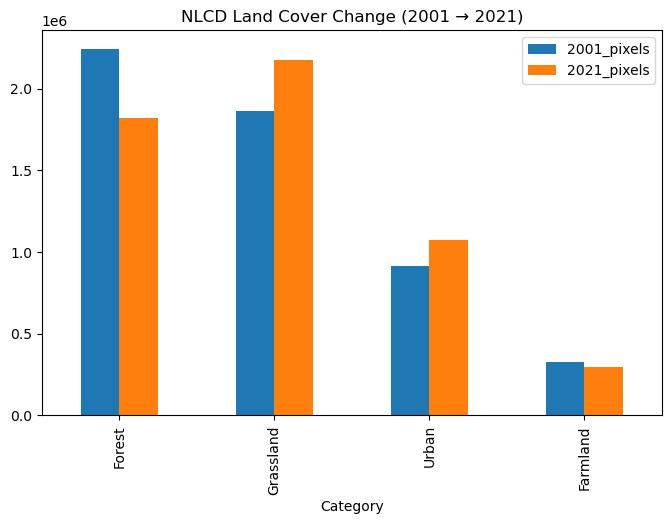

In [15]:
# Category → NLCD class codes
CATEGORIES = {
    "Forest": [41, 42, 43],
    "Grassland": [52, 71, 72],
    "Urban": [21, 22, 23, 24],
    "Farmland": [81, 82]
}

def summarize_categories(counts_dict):
    """Convert raw NLCD class histogram into grouped category totals."""
    summary = {}
    for cat, codes in CATEGORIES.items():
        summary[cat] = sum(counts_dict.get(str(code), 0) for code in codes)
    return summary

summary_2001 = summarize_categories(counts_2001)
summary_2021 = summarize_categories(counts_2021)

df = pd.DataFrame({
    "Category": list(CATEGORIES.keys()),
    "2001_pixels": [summary_2001[c] for c in CATEGORIES],
    "2021_pixels": [summary_2021[c] for c in CATEGORIES],
})

df["Change_pixels"] = df["2021_pixels"] - df["2001_pixels"]
df["Change_percent"] = 100 * df["Change_pixels"] / df["2001_pixels"]
df

df.set_index("Category")[["2001_pixels", "2021_pixels"]].plot.bar(
    figsize=(8,5), title="NLCD Land Cover Change (2001 → 2021)"
)

In [16]:
# Convert pixel counts to area in hectares
# NLCD pixel size = 30 m × 30 m = 900 m² = 0.09 ha

PIXEL_AREA_HA = 0.09

df["2001_area_ha"] = df["2001_pixels"] * PIXEL_AREA_HA
df["2021_area_ha"] = df["2021_pixels"] * PIXEL_AREA_HA
df["Change_area_ha"] = df["2021_area_ha"] - df["2001_area_ha"]

# Optional: convert hectares to square kilometers
df["2001_area_km2"] = df["2001_area_ha"] / 100
df["2021_area_km2"] = df["2021_area_ha"] / 100
df["Change_area_km2"] = df["Change_area_ha"] / 100

# Reorder columns for clearer display
area_change_df = df[
    [
        "Category",
        "2001_area_ha",
        "2021_area_ha",
        "Change_area_ha",
        "Change_percent",
        "2001_area_km2",
        "2021_area_km2",
        "Change_area_km2"
    ]
]

area_change_df.round(2)

,Category,2001_area_ha,2021_area_ha,Change_area_ha,Change_percent,2001_area_km2,2021_area_km2,Change_area_km2
0,Forest,202112.73,163616.25,-38496.47,-19.05,2021.13,1636.16,-384.96
1,Grassland,167748.69,195883.14,28134.45,16.77,1677.49,1958.83,281.34
2,Urban,82501.94,96460.48,13958.54,16.92,825.02,964.60,139.59
3,Farmland,29271.21,26440.47,-2830.74,-9.67,292.71,264.40,-28.31


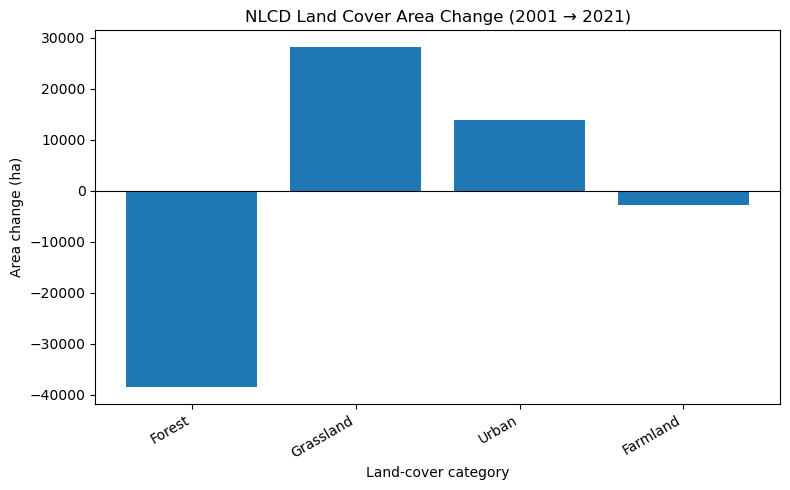

✅ Saved -> figures/nlcd_area_change_2001_2021.png


In [17]:
# Plot area change from 2001 to 2021

plt.figure(figsize=(8, 5))

plt.bar(
    area_change_df["Category"],
    area_change_df["Change_area_ha"]
)

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("Land-cover category")
plt.ylabel("Area change (ha)")
plt.title("NLCD Land Cover Area Change (2001 → 2021)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    "figures/nlcd_area_change_2001_2021.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved -> figures/nlcd_area_change_2001_2021.png")

In [ ]:
########################  elevation  #############################

# Load and clip elevation data
dem = ee.Image('USGS/3DEP/10m').clip(study_area)

# Calculate elevation statistics
elev_stats = dem.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=study_area,
    scale=10,
    maxPixels=1e9,
    bestEffort=True
).getInfo()

elev_min = elev_stats['elevation_min']
elev_max = elev_stats['elevation_max']

print(f'Minimum elevation: {elev_min:.2f} m')
print(f'Maximum elevation: {elev_max:.2f} m')

Minimum elevation: 1479.70 m
Maximum elevation: 3281.42 m


In [25]:
# Visualization parameters based on actual elevation range
elev_vis = {
    'min': elev_min,
    'max': elev_max,
    'palette': [
        '#2b83ba',
        '#abdda4',
        '#ffffbf',
        '#fdae61',
        '#d7191c'
    ]
}

# Create map
Map6 = geemap.Map(
    center=[
        (lat_north + lat_south) / 2,
        (lon_west + lon_east) / 2
    ],
    zoom=9
)

Map6.addLayer(dem, elev_vis, 'Elevation (m)')
Map6.add_colorbar(elev_vis, label='Elevation (m)')

show_map(Map6)

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [26]:
slope_stats = slope.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=study_area,
    scale=10,
    maxPixels=1e9,
    bestEffort=True
).getInfo()

print(slope_stats)

{'slope_max': 82.35032653808594, 'slope_min': 0}


In [27]:
slope = ee.Terrain.slope(dem)

slope_vis = {'min': 0, 'max': 30,
             'palette': ['#f7fcf5', '#74c476', '#238b45', '#00441b']}

Map7 = geemap.Map(center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2], zoom=9)
Map7.addLayer(slope, slope_vis, 'Slope (degrees)')
Map7.add_colorbar(slope_vis, label='Slope (degrees)')
show_map(Map7)

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [43]:
########################### Combine elevation and land-cover bands ###############################
combined = dem.addBands(nlcd_2021)

print('Combined image bands:')
print(combined.bandNames().getInfo())

# Randomly sample pixels within the study area
samples = combined.sample(
    region=study_area,
    scale=30,              # Match NLCD's 30 m resolution
    numPixels=2000,
    seed=42,
    geometries=False,
    dropNulls=True
)

# Convert Earth Engine samples to a Pandas DataFrame
df_samples = geemap.ee_to_df(samples, remove_geom=False)

print(f'Sampled {len(df_samples):,} valid pixels')
print('\nData columns:')
print(df_samples.columns.tolist())

print('\nFirst five rows:')
display(df_samples.head())

Combined image bands:
['elevation', 'landcover']
Sampled 2,000 valid pixels

Data columns:
['geo', 'elevation', 'landcover']

First five rows:


,geo,elevation,landcover
0,None,2394.709717,42
1,None,2255.105713,42
2,None,1847.787231,22
3,None,1612.906982,22
4,None,1549.785889,81


In [ ]:
 # Define NLCD class names
nlcd_name_map = {
    11: 'Water',
    12: 'Perennial Ice/Snow',

    21: 'Dev-Open', # Developed, Open Space
    22: 'Dev-Low', # Developed, Low Intensity
    23: 'Dev-Med', # Developed, Medium Intensity
    24: 'Dev-High', # Developed, High Intensity

    31: 'Barren Land',

    41: 'Deciduous Forest',
    42: 'Evergreen Forest',
    43: 'Mixed Forest',

    52: 'Shrub/Scrub',

    71: 'Grassland',

    81: 'Pasture/Hay',
    82: 'Cultivated Crops',

    90: 'Woody Wetlands',
    95: 'Emergent Herbaceous Wetlands'
}

# Define colors for NLCD classes
nlcd_color_map = {
    'Water': '#47b7eb',
    'Perennial Ice/Snow': '#a5edf5',

    'Dev-Open': '#eda1a1',
    'Dev-Low': '#e87f7f',
    'Dev-Med': '#ed0000',
    'Dev-High': '#ab0000',

    'Barren Land': '#d4c798',

    'Deciduous Forest': '#68ab63',
    'Evergreen Forest': '#1c6330',
    'Mixed Forest': '#a0d18d',

    'Shrub/Scrub': '#ccb879',

    'Grassland': '#e3d28e',

    'Pasture/Hay': '#dbd93d',
    'Cultivated Crops': '#ab7028',

    'Woody Wetlands': '#9eaf9e',
    'Emergent Herbaceous Wetlands': '#c6d18c'
}


In [36]:
# Convert numeric NLCD codes to names
# Ensure landcover is numeric
df_samples['landcover'] = pd.to_numeric(
    df_samples['landcover'],
    errors='coerce'
)

df_samples['Land Cover'] = (
    df_samples['landcover']
    .map(nlcd_name_map)
)

# Remove missing or unrecognized records
df_samples = df_samples.dropna(
    subset=['elevation', 'Land Cover']
).copy()

# Find the six most common land-cover classes
class_counts = df_samples['Land Cover'].value_counts()

print('\nSample counts by land-cover class:')
print(class_counts)

top_classes = (
    class_counts
    .head(6)
    .index
    .tolist()
)

print('\nTop six classes:')
print(top_classes)

# Keep only the six most common classes
df_plot = df_samples[
    df_samples['Land Cover'].isin(top_classes)
].copy()

# Assign colors in the same order as top_classes
colors = [
    nlcd_color_map.get(class_name, '#999999')
    for class_name in top_classes
]


Sample counts by land-cover class:
Land Cover
Evergreen Forest                631
Shrub/Scrub                     444
Grassland                       328
Dev-Low                         154
Dev-Open                        105
Dev-Med                         102
Cultivated Crops                 65
Pasture/Hay                      39
Water                            34
Emergent Herbaceous Wetlands     31
Dev-High                         25
Woody Wetlands                   22
Deciduous Forest                 16
Barren Land                       3
Mixed Forest                      1
Name: count, dtype: int64

Top six classes:
['Evergreen Forest', 'Shrub/Scrub', 'Grassland', 'Dev-Low', 'Dev-Open', 'Dev-Med']


In [37]:
# Print elevation summary statistics
elevation_summary = (
    df_plot
    .groupby('Land Cover')['elevation']
    .agg(
        sample_count='count',
        minimum='min',
        median='median',
        mean='mean',
        maximum='max'
    )
    .reindex(top_classes)
    .round(1)
)

print('\nElevation summary by land-cover class:')
display(elevation_summary)


Elevation summary by land-cover class:


,sample_count,minimum,median,mean,maximum
Land Cover,,,,,
Evergreen Forest,631,1723.8,2354.0,2350.3,3150.1
Shrub/Scrub,444,1523.1,2018.9,2057.2,3058.0
Grassland,328,1513.2,1750.0,1903.7,3151.1
Dev-Low,154,1503.6,1653.9,1700.9,2689.0
Dev-Open,105,1510.6,1667.2,1794.0,2892.0
Dev-Med,102,1507.0,1649.0,1648.1,2015.8


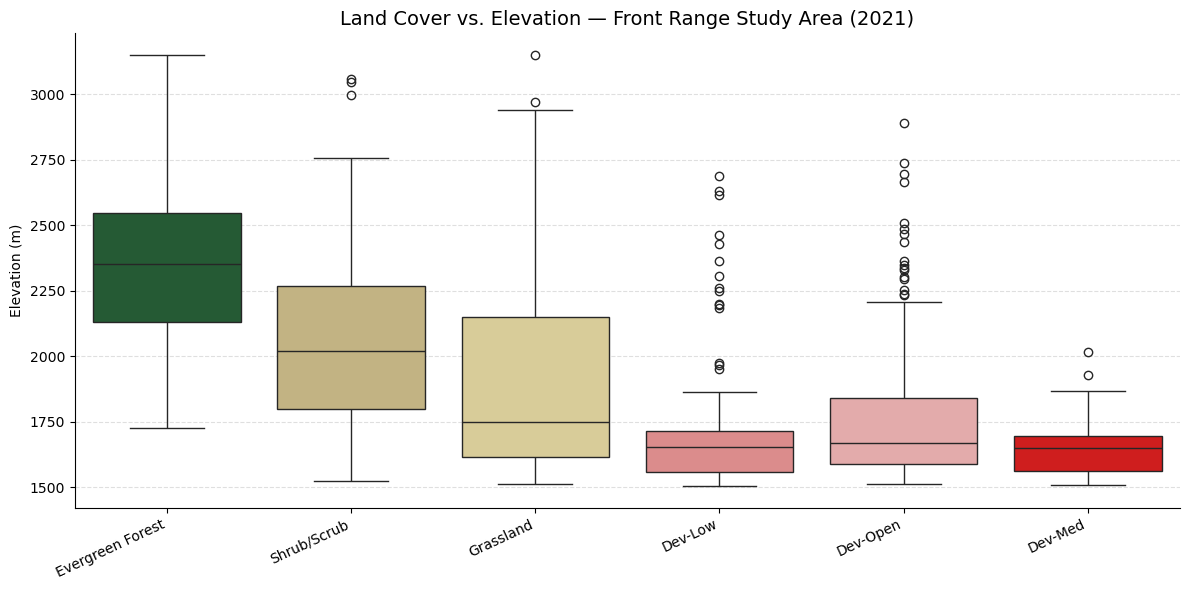

In [39]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df_plot,
    x='Land Cover',
    y='elevation',
    order=top_classes,
    palette=dict(zip(top_classes, colors)),
    hue='Land Cover',
    hue_order=top_classes,
    legend=False,
    ax=ax
)

ax.set_title(
    'Land Cover vs. Elevation — Front Range Study Area (2021)',
    fontsize=14
)

ax.set_xlabel('')
ax.set_ylabel('Elevation (m)')

# Rotate labels to prevent overlap
plt.setp(
    ax.get_xticklabels(),
    rotation=25,
    ha='right'
)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add light horizontal grid lines
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()


In [40]:
# Save the figure
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    'csu_landcover_vs_elevation.png'
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'✅ Saved → {output_path}')

<Figure size 640x480 with 0 Axes>

✅ Saved → figures/csu_landcover_vs_elevation.png


In [ ]:
# Higher-elevation areas are primarily associated with evergreen forest and shrub/scrub
# Developed land-cover classes are concentrated at lower elevations
# Grassland spans a relatively broad elevation range across the Front Range study area.

Elevation range: 1492.1 m to 3151.1 m


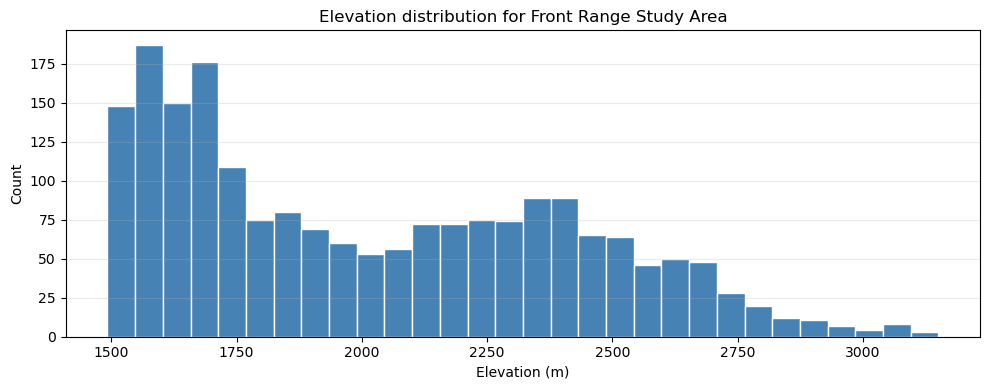

In [42]:
# elevation histogram
plt.figure(figsize=(10, 4))
elev = df_samples['elevation'].dropna()
plt.hist(elev, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Elevation (m)')
plt.ylabel('Count')
plt.title('Elevation distribution for Front Range Study Area')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
min_elev, max_elev = elev.min(), elev.max()
print(f'Elevation range: {min_elev:.1f} m to {max_elev:.1f} m')
plt.show()

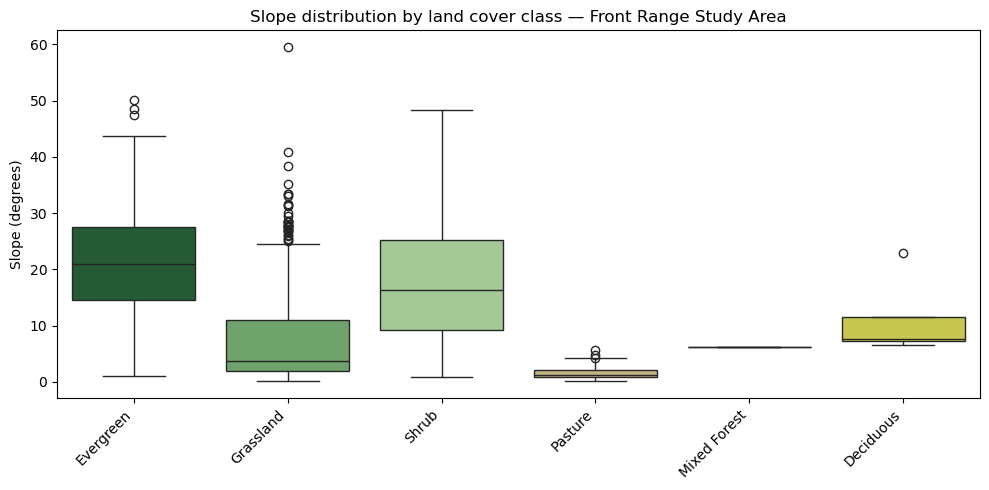

Land Cover
Evergreen       20.964877
Shrub           16.291197
Deciduous        7.715755
Mixed Forest     6.174453
Grassland        3.736442
Pasture          1.315226
Name: slope, dtype: float64


In [44]:
# Re-define foothills_aoi as it was when df_samples was originally created (from cell RrOQqZ0W4FME's earlier state)
foothills_aoi = ee.Geometry.Point([(lon_west + lon_east) / 2, (lat_north + lat_south) / 2]).buffer(15000).bounds()

# Re-load NLCD 2021, clipped to foothills_aoi (duplicating part of cell 5ihEqAIj4pKG)
nlcd_foothills = (ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD')
                  .filter(ee.Filter.eq('system:index', '2021'))
                  .first().select('landcover').clip(foothills_aoi))

# Combine dem, nlcd_foothills, and slope (renaming 'slope' band) for sampling
# 'dem' and 'slope' EE images are available globally from upstream cells.
combined_for_sampling = dem.addBands(nlcd_foothills.addBands(slope.rename('slope')))

# Re-sample the combined image to create df_samples with the 'slope' column
samples_with_slope = combined_for_sampling.sample(
    region=foothills_aoi, scale=30,
    numPixels=2000, seed=42, geometries=False
)

df_samples = geemap.ee_to_df(samples_with_slope, remove_geom=False)

# ✏️ Exercise 4c — slope boxplot (stretch)
nlcd_name_map = {
    11:'Water', 12:'Perennial Ice/Snow', 21:'Dev-Open', 22:'Dev-Low', 23:'Dev-Med', 24:'Dev-High',
    31:'Barren Land', 41:'Deciduous', 42:'Evergreen', 43:'Mixed Forest',
    52:'Shrub', 71:'Grassland', 81:'Pasture', 82:'Crops', 90:'Woody Wetlands', 95:'Emergent Herbaceous Wetlands'
}
nlcd_color_map = {
    'Dev-Open':'#eda1a1', 'Dev-Low':'#e87f7f', 'Dev-Med':'#ed0000', 'Dev-High':'#ab0000',
    'Evergreen':'#1c6330', 'Deciduous':'#68ab63', 'Grassland':'#e3d28e',
    'Shrub':'#ccb879', 'Pasture':'#dbd93d', 'Crops':'#ab7028',
    'Water': '#47b7eb', 'Perennial Ice/Snow': '#a5edf5', 'Barren Land': '#d4c798',
    'Mixed Forest': '#a0d18d', 'Woody Wetlands': '#9eaf9e', 'Emergent Herbaceous Wetlands': '#c6d18c'
}
df_samples['Land Cover'] = df_samples['landcover'].map(nlcd_name_map)
df_samples = df_samples.dropna(subset=['Land Cover'])
top_classes = ['Evergreen', 'Deciduous', 'Mixed Forest', 'Shrub', 'Grassland', 'Pasture']
df_plot = df_samples[df_samples['Land Cover'].isin(top_classes)]
colors = [nlcd_color_map.get(c, '#999999') for c in top_classes]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_plot, x='Land Cover', y='slope', palette=colors)
plt.ylabel('Slope (degrees)')
plt.xlabel('')
plt.title('Slope distribution by land cover class — Front Range Study Area')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

median_slopes = df_plot.groupby('Land Cover')['slope'].median().sort_values(ascending=False)
print(median_slopes)

In [46]:
##### Map DEM elevation within the study area to verify the west-to-east mountain-to-plains gradient
##### for elevation-based forest change analysis
# Load DEM
dem = ee.Image('USGS/3DEP/10m').select('elevation').clip(study_area)

# DEM visualization
dem_vis = {
'min': 1400,
'max': 3000,
'palette': ['#F7FCF5', '#C7E9C0', '#74C476', '#238B45', '#00441B']
}

Map = geemap.Map(
center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2],
zoom=9
)
Map.addLayer(study_area, {'color': 'red'}, 'Study Area')
Map.addLayer(dem, dem_vis, 'Elevation')
Map.add_colorbar(dem_vis, label='Elevation (m)')
Map

# Create low, middle, and high elevation bands for the study area

# Load DEM and clip to study area
dem = ee.Image('USGS/3DEP/10m').select('elevation').clip(study_area)

# Check elevation statistics within the study area
elev_stats = dem.reduceRegion(
reducer=ee.Reducer.minMax().combine(
reducer2=ee.Reducer.mean(),
sharedInputs=True),
geometry=study_area,
scale=30,
maxPixels=1e9
).getInfo()

print("Elevation statistics:", elev_stats)

Elevation statistics: {'elevation_max': 3275.802734375, 'elevation_mean': 2014.1831577144883, 'elevation_min': 1479.699951171875}


In [49]:
# Define elevation thresholds
low = dem.lt(1700)
mid = dem.gte(1700).And(dem.lt(2300))
high = dem.gte(2300)

# Combine into a single image
elev_classes = (
    low.multiply(1)
    .add(mid.multiply(2))
    .add(high.multiply(3))
)

class_vis = {
    'min': 1,
    'max': 3,
    'palette': ['#edf8fb', '#b2e2e2', '#2ca25f']  # low, mid, high
}

Map.addLayer(elev_classes, class_vis, 'Elevation Classes')
Map

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [ ]:
#combining nlcd and dem...
stack = nlcd_change.addBands(elev_classes.rename('elev_band'))

#ok so this is looking at land cover transitions per elevation band....
transition_stats = stack.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=study_area,
    scale=30,
    maxPixels=1e9
)

#making transitions as single integers, ie if land cover changes from 52 > 71, the area's identifier is now 52071
transition = nlcd_2001.multiply(100).add(nlcd_2021)
#adding elevation bands
stack2 = transition.rename('transition').addBands(elev_classes.rename('elev_band'))

#make histogram
stats = stack2.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=study_area,
    scale=30,
    maxPixels=1e9
).getInfo()

print("Transition histogram:")
print(stats)

def get_band_stats(band_value):
    mask = elev_classes.eq(band_value)
    masked_transition = transition.updateMask(mask)

    return masked_transition.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=study_area,
        scale=30,
        maxPixels=1e9
    ).getInfo()
    


Transition histogram:
{'elev_band': {'1': 1833073.811764706, '2': 2209765.4470588225, '3': 1580250.9372548994}, 'transition': {'1111': 99107.76862745098, '1121': 265.94117647058823, '1122': 210.6235294117647, '1123': 315.47058823529414, '1124': 121.2392156862745, '1131': 113, '1141': 11, '1142': 225, '1143': 3, '1152': 63.87450980392157, '1171': 920.7137254901961, '1181': 17, '1182': 19, '1190': 372, '1195': 3183.0901960784313, '2121': 254501.43137254904, '2122': 5323.266666666667, '2123': 15279.047058823531, '2124': 3074.9098039215687, '2152': 4, '2171': 30, '2181': 5, '2182': 5, '2222': 353845.69803921564, '2223': 5991.474509803922, '2224': 5023.431372549019, '2242': 7, '2252': 6, '2271': 10, '2323': 212023.0666666667, '2324': 609.7960784313725, '2342': 2, '2371': 4, '2424': 60941.05098039215, '2471': 2, '3111': 389, '3121': 102, '3122': 190, '3123': 484.34901960784316, '3124': 272, '3131': 4854.619607843137, '3141': 2, '3142': 2, '3152': 135, '3171': 299, '3182': 3, '3190': 2, '3195

In [55]:
low_stats = get_band_stats(1)
mid_stats = get_band_stats(2)
high_stats = get_band_stats(3)

print(low_stats)

{'landcover': {'1111': 83911.14117647058, '1121': 207.94117647058823, '1122': 182.6235294117647, '1123': 253.47058823529412, '1124': 95.23921568627452, '1131': 113, '1141': 11, '1142': 60, '1143': 3, '1152': 23.87450980392157, '1171': 758.7137254901961, '1181': 17, '1182': 19, '1190': 352, '1195': 3035.0901960784313, '2121': 158148.2588235294, '2122': 3075.866666666667, '2123': 10328.529411764706, '2124': 2326.9098039215687, '2152': 3, '2171': 27, '2181': 5, '2182': 5, '2222': 256594.462745098, '2223': 4157.0745098039215, '2224': 3793.141176470588, '2252': 3, '2271': 10, '2323': 158735.63529411767, '2324': 451.79607843137256, '2371': 4, '2424': 47462.0431372549, '2471': 2, '3111': 159, '3121': 47, '3122': 78, '3123': 241.34901960784313, '3124': 124, '3131': 2976.619607843137, '3141': 1, '3152': 71, '3171': 223, '3182': 3, '3190': 2, '3195': 2, '4111': 59.40392156862745, '4121': 211, '4122': 103, '4123': 63, '4124': 17, '4131': 1, '4141': 2832.2745098039213, '4142': 3, '4143': 1, '4152'

In [59]:
def decode_transition(code):
    code = int(code)
    old = code // 100
    new = code % 100
    return old, new

low_transitions = low_stats['landcover']

increase = {}
decrease = {}

for code, count in low_transitions.items():
    old, new = decode_transition(code)
    if old != new:
        decrease[old] = decrease.get(old, 0) + count
        increase[new] = increase.get(new, 0) + count

print("Low band increases:", increase)
print("Low band decreases:", decrease)

Low band increases: {21: 23486.858823529412, 22: 19609.419607843138, 23: 40463.60784313725, 24: 13660.713725490195, 31: 565.2745098039215, 41: 121.99607843137255, 42: 172, 43: 34, 52: 2600.043137254902, 71: 25121.800000000003, 81: 11844.011764705881, 82: 16639.84705882353, 90: 1796.9725490196079, 95: 7493.58431372549, 11: 10005.133333333335}
Low band decreases: {11: 5131.952941176471, 21: 15771.305882352943, 22: 7963.21568627451, 23: 455.79607843137256, 24: 2, 31: 951.3490196078432, 41: 621.4039215686274, 42: 536, 43: 62.99607843137255, 52: 3718.3450980392154, 71: 56843.1137254902, 81: 13244.109803921569, 82: 46210.92549019608, 90: 7107.2235294117645, 95: 14995.525490196078}
